# 02 · Preprocessing pipeline

Starts from the raw, conclusion-free tables in `data/raw_tables/`.
Every decision about the data (deduplication, analyte mapping, which extraction to trust, event adjudication) is made here, in code, so it can be rerun and reviewed.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "notebooks"))
from pipeline import viz

viz.use_style()
RAW = ROOT / "data" / "raw_tables"
assert RAW.exists(), f"raw tables not found at {RAW}; run scripts/03_build_raw_tables.py first"

## 0. The raw tables, before any decision

`scripts/03_build_raw_tables.py` writes 15 tables. They fall into two groups:

- **From the source files:** the three Excel extracts, unchanged apart from added ids, duplicate flags and parsed numbers. `diagnoses` and `rxnorm_codes` are JSON columns of the medications file split into rows.
- **From the notes:** facts pulled out of the note text. Most of these tables hold two readings of the same note, one by pattern-matching rules and one by the language model, told apart by the `method` column. Nothing has been reconciled yet; that is the job of the steps below.



In [2]:
raw = {p.stem: pd.read_parquet(p) for p in sorted(RAW.glob("*.parquet"))}

CONTENTS = {
    "patients": ("source files", "one row per patient: which files cover them and how many rows each has"),
    "notes": ("source files", "one row per note: type, service, signature status, years, length, redaction counts (no text)"),
    "labs_raw": ("source files", "every lab row, plus duplicate flag, parsed number, censoring flag, parsed reference range"),
    "meds_raw": ("source files", "every medication row, plus duplicate flag"),
    "diagnoses": ("source files", "ICD-10 codes attached to medication orders"),
    "rxnorm_codes": ("source files", "RxNorm concept codes attached to medication orders"),
    "note_operations": ("from notes", "the operation a note documents: SAVR or TAVR, valve model, size, access, concomitant procedures"),
    "note_prosthesis_status": ("from notes", "whether the patient already has a prosthetic aortic valve, with model and implant date as written"),
    "echo_measurements": ("from notes", "one row per echo value: parameter, number, unit, native or prosthetic valve, before or after surgery"),
    "prosthesis_statements": ("from notes", "quoted sentences about how the prosthesis works, with a category"),
    "reinterventions": ("from notes", "repeat procedures on the aortic valve, with reason as written"),
    "events_regex": ("from notes", "keyword hits for failure, leak, endocarditis, thrombosis, mismatch, with a negation flag"),
    "clinical_context": ("from notes", "sex, body size, symptoms, comorbidities and therapy as written"),
    "dates_in_text": ("from notes", "dates that survived redaction inside the text"),
    "extraction_notes": ("from notes", "the model's remarks on ambiguities and contradictions in each note"),
}

def short_method(m):
    return m.fillna("").str.extract(r"^(notes-llm|notes-regex|regex)")[0].replace({"notes-llm": "model", "notes-regex": "rules", "regex": "rules"})

rows = []
for name, (group, contents) in CONTENTS.items():
    d = raw[name]
    pid = "patient" if "patient" in d else "Patient"
    readings = ", ".join(sorted(short_method(d["method"]).dropna().unique())) if "method" in d else ""
    rows.append(dict(table=name, group=group, rows=len(d), columns=d.shape[1], patients=d[pid].nunique(),
                     notes=d["note_id"].nunique() if "note_id" in d else None, readings=readings, contents=contents))
catalogue = pd.DataFrame(rows).set_index("table")
catalogue.style.format({"rows": "{:,}", "notes": "{:.0f}"}, na_rep="").set_properties(subset=["contents"], **{"text-align": "left", "white-space": "normal"})

,group,rows,columns,patients,notes,readings,contents
table,,,,,,,
patients,source files,117,8,117,,,one row per patient: which files cover them and how many rows each has
notes,source files,215,17,117,215,,"one row per note: type, service, signature status, years, length, redaction counts (no text)"
labs_raw,source files,"43,550",26,17,,,"every lab row, plus duplicate flag, parsed number, censoring flag, parsed reference range"
meds_raw,source files,"5,807",28,17,,,"every medication row, plus duplicate flag"
diagnoses,source files,35,7,10,,,ICD-10 codes attached to medication orders
rxnorm_codes,source files,"140,792",3,17,,,RxNorm concept codes attached to medication orders
note_operations,from notes,327,22,117,215,"model, rules","the operation a note documents: SAVR or TAVR, valve model, size, access, concomitant procedures"
note_prosthesis_status,from notes,287,11,117,215,"model, rules","whether the patient already has a prosthetic aortic valve, with model and implant date as written"
echo_measurements,from notes,"2,733",14,110,178,"model, rules","one row per echo value: parameter, number, unit, native or prosthetic valve, before or after surgery"


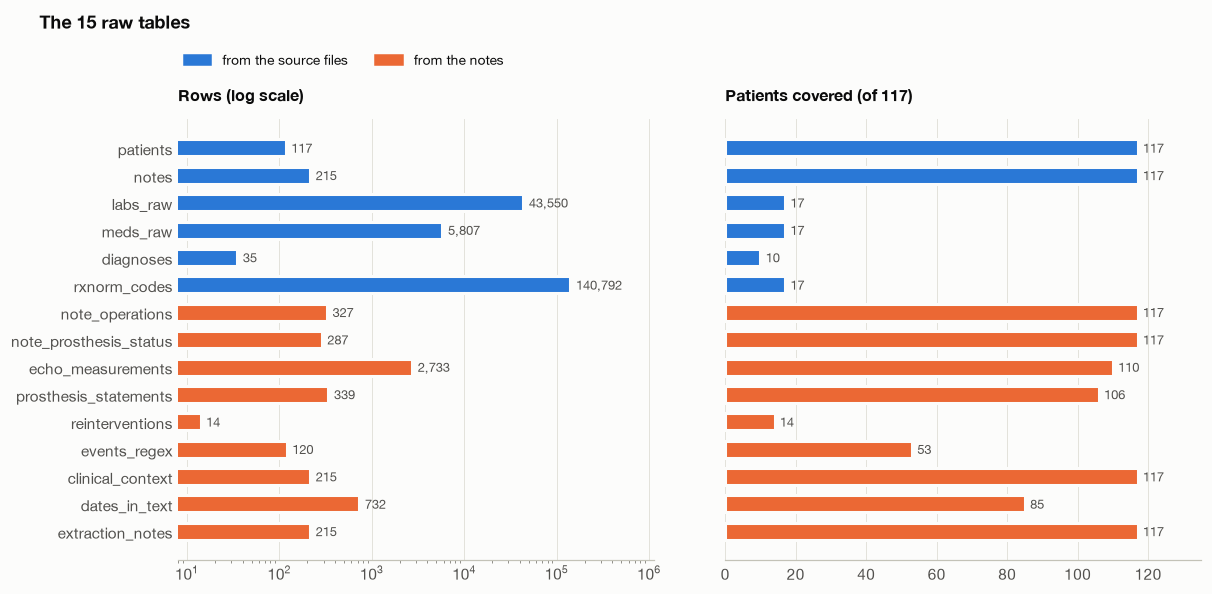

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), sharey=True, gridspec_kw=dict(wspace=0.15))
order = catalogue.index.tolist()
colors = [viz.SERIES[0] if g == "source files" else viz.SERIES[1] for g in catalogue.group]
y = np.arange(len(order))
axes[0].barh(y, catalogue.rows, height=0.62, color=colors, edgecolor=viz.SURFACE, linewidth=2)
axes[0].set_xscale("log")
axes[0].set_title("Rows (log scale)", fontsize=10.5)
for i, v in enumerate(catalogue.rows):
    axes[0].text(v * 1.15, i, f"{v:,}", va="center", fontsize=8.5, color=viz.INK_SECONDARY)
axes[0].set_xlim(8, catalogue.rows.max() * 8)
axes[1].barh(y, catalogue.patients, height=0.62, color=colors, edgecolor=viz.SURFACE, linewidth=2)
axes[1].set_title("Patients covered (of 117)", fontsize=10.5)
axes[1].set_xlim(0, 135)
for i, v in enumerate(catalogue.patients):
    axes[1].text(v + 1.5, i, f"{v}", va="center", fontsize=8.5, color=viz.INK_SECONDARY)
axes[0].set_yticks(y, order)
axes[0].invert_yaxis()
for ax in axes:
    ax.grid(axis="y", visible=False)
handles = [plt.Rectangle((0, 0), 1, 1, color=viz.SERIES[i]) for i in range(2)]
fig.legend(handles, ["from the source files", "from the notes"], loc="upper left", bbox_to_anchor=(0.12, 1.02), ncol=2, fontsize=9)
fig.suptitle("The 15 raw tables", x=0.02, y=1.07, ha="left", fontweight="bold")
viz.save(fig, "02_raw_tables")
plt.show()

### What the note extraction found

Echo values are the core of the endpoint, so this is the table that matters most. The model reading groups values into studies and labels each one as native or prosthetic valve and as before or after surgery; the rules reading has values only. Quoted statements about the prosthesis are the raw material for the event list the clinician adjudicates.

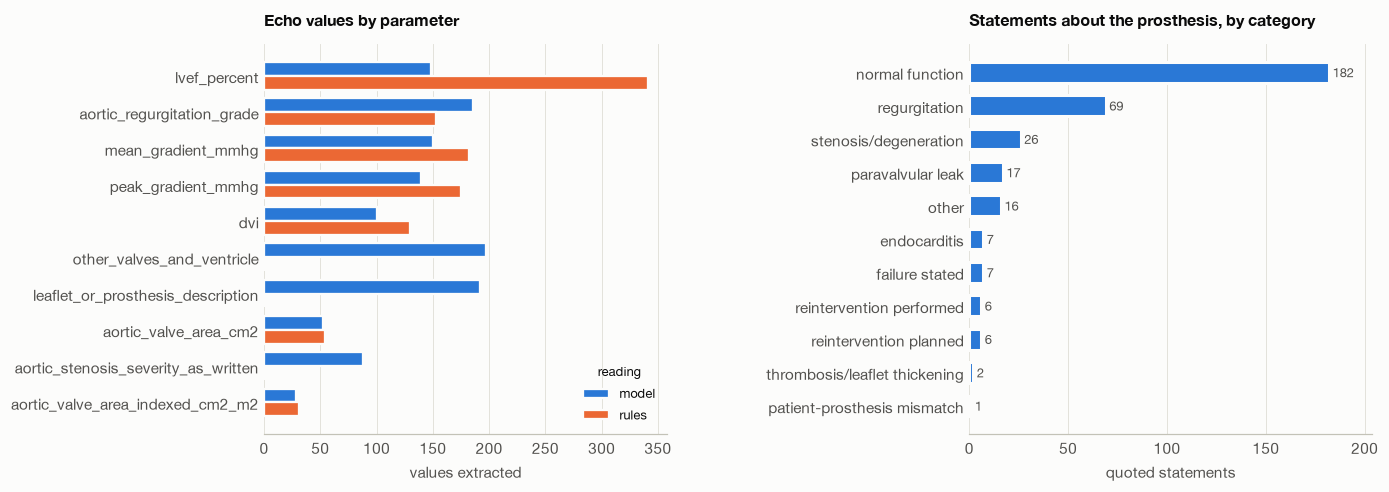

"timing (model reading, one row per echo study)",post-operative,pre-operative,unclear,total
valve assessed,,,,
native,0,94,0,94
prosthetic,193,13,0,206
unclear,11,5,6,22
total,204,112,6,322


In [4]:
E = raw["echo_measurements"].assign(reading=lambda d: short_method(d.method))
E = E[E.parameter != "study_recorded"]
top = E.parameter.value_counts().head(10).index
by = E[E.parameter.isin(top)].groupby(["parameter", "reading"]).size().unstack(fill_value=0).reindex(top)
S = raw["prosthesis_statements"].category.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw=dict(wspace=0.75))
y = np.arange(len(by))
h = 0.38
for i, col in enumerate(["model", "rules"]):
    axes[0].barh(y + (i - 0.5) * h, by[col], height=h, color=viz.SERIES[i], edgecolor=viz.SURFACE, linewidth=1.5, label=col)
axes[0].set_yticks(y, by.index)
axes[0].invert_yaxis()
axes[0].grid(axis="y", visible=False)
axes[0].legend(title="reading", fontsize=8.5, title_fontsize=8.5)
axes[0].set_title("Echo values by parameter", fontsize=10.5)
axes[0].set_xlabel("values extracted")
viz.hbar(axes[1], list(S.index), list(S.values), xlabel="quoted statements")
axes[1].set_title("Statements about the prosthesis, by category", fontsize=10.5)
viz.save(fig, "02_note_extraction")
plt.show()

m = raw["echo_measurements"]
m = m[short_method(m.method) == "model"].drop_duplicates(["note_id", "study_index"])
pd.crosstab(m.valve_assessed.fillna("not stated"), m.timing.fillna("not stated"), margins=True, margins_name="total").rename_axis(index="valve assessed", columns="timing (model reading, one row per echo study)")

### Column guide

`column_guide(name)` lists every column of a raw table with its type, how often it is filled and how many distinct values it has. Use it before writing a step that touches a table.

In [5]:
def column_guide(name):
    d = raw[name]
    return pd.DataFrame({
        "type": d.dtypes.astype(str),
        "filled": d.notna().mean().map("{:.0%}".format),
        "distinct values": d.nunique(),
    }).rename_axis(f"{name} column")

column_guide("echo_measurements")

,type,filled,distinct values
echo_measurements column,,,
note_id,str,100%,178
patient,str,100%,110
service_year,int64,100%,19
method,str,100%,2
study_index,float64,61%,9
study_label,str,61%,219
date_as_written,str,30%,21
timing,str,61%,3
valve_assessed,str,88%,4


In [6]:
patients = raw["patients"]
notes = raw["notes"]
note_operations = raw["note_operations"]
note_prosthesis_status = raw["note_prosthesis_status"]
echo_measurements = raw["echo_measurements"]
prosthesis_statements = raw["prosthesis_statements"]
reinterventions = raw["reinterventions"]
events_regex = raw["events_regex"]
clinical_context = raw["clinical_context"]
dates_in_text = raw["dates_in_text"]
extraction_notes = raw["extraction_notes"]
labs_raw = raw["labs_raw"]
meds_raw = raw["meds_raw"]
diagnoses = raw["diagnoses"]
rxnorm_codes = raw["rxnorm_codes"]

## Pipeline

The logic lives in `notebooks/pipeline/prep.py`, one function per step. Every judgement call is a key in `prep.CONFIG`, shown below, so a sensitivity analysis is a loop over configs (last section). Outputs go to `data/processed/` (gitignored). Only counts and distributions are shown here.

In [7]:
import os
import importlib
from pipeline import prep
importlib.reload(prep)

OUT = Path(os.environ.get("AVR_REAL_DIR", ROOT / "data" / "processed"))
OUT.mkdir(exist_ok=True)
ADJUDICATION_CSV = ROOT / "data" / "event_adjudication.csv"
CONFIG = dict(prep.CONFIG)
pd.Series(CONFIG, name="value").to_frame()

,value
drop_exact_duplicates,True
last_valid_year,2026
lab_lookback_years,2
med_modes,"(Outpatient,)"
reference_window_years,1
reference_prefers_gradient,True
fill_from_rules,True
ppm_excludes_echo_events,False
use_written_dates,True
event_year_rule,midpoint


## 1. Cohort

Who is in the study. A patient is included when any note shows an aortic valve prosthesis: an operative report, an operation read from a procedure note or discharge summary, or a history statement that the patient has a prosthetic aortic valve.

Check: every excluded patient has a stated reason.

In [8]:
cohort = prep.build_cohort(raw)
assert cohort.loc[~cohort.included, "exclusion_reason"].ne("").all()
cohort.groupby(["group", "included"]).agg(patients=("patient", "size"), with_operative_report=("has_operative_report", "sum"))

patients  with_operative_report
group                               included                                 
operative notes, no structured data True           100                    100
structured history, one note        False            1                      0
                                    True            16                      0

## 2. Remove exact duplicate rows

Input: `labs_raw`, `meds_raw`. A row is dropped when every source column matches an earlier row.

Each kept row carries `n_copies`, the number of identical rows it stood for. For medications the repeats are mostly repeated administrations of the same order in the same year, so `n_copies` approximates the number of doses. For labs, the large repeat groups are transcriptions and respiratory flowsheets, which step 3 drops; for real analytes the median is one, and a higher count means the same value was reported more than once that year. Dates are years only, so these copies cannot be told apart from true repeats. Features use the last, minimum or maximum value per window, which copies cannot change, and `n_copies` is kept for provenance rather than used as a feature.

Check: 19,002 lab rows and 2,157 medication rows remain.

In [9]:
labs = prep.dedupe(labs_raw, CONFIG)
meds = prep.dedupe(meds_raw, CONFIG)
assert (len(labs), len(meds)) == (19002, 2157)
pd.DataFrame({"before": [len(labs_raw), len(meds_raw)], "after": [len(labs), len(meds)]}, index=["labs", "medications"])

,before,after
labs,43550,19002
medications,5807,2157


## 3. Lab results: keep analytes, map names and units

The labs file also holds transcriptions, blood gases, device checks and blood bank records. An explicit dictionary (`prep.ANALYTES`) lists the component names that count as each analyte. LOINC is on a third of rows, so it cannot be the rule.

Decisions:
- eGFR uses the `All Other Races` component and drops the race-specific duplicate.
- Urine creatinine is not serum creatinine and is left out.
- Censored values such as `>60` keep their number with `is_censored` set.
- Rows dated after the last real year (the 2027 shift artefact) are dropped.

Output: `lab_clean` (patient, year, analyte, value, unit, is_censored) and `lab_other` (everything else, kept for reference).

Check: one unit per analyte.

In [10]:
lab_clean, lab_other = prep.clean_labs(labs, CONFIG)
units = lab_clean.groupby("analyte").unit.nunique()
assert units.eq(1).all()
summary = lab_clean.groupby("analyte").agg(rows=("value", "size"), patients=("patient", "nunique"), unit=("unit", "first"),
                                           median=("value", "median"), censored=("is_censored", "sum"), first_year=("year", "min"), last_year=("year", "max"))
display(summary)
lab_other["Lab Component Name"].value_counts().head(8).rename("rows left out (top 8)").to_frame()

,rows,patients,unit,median,censored,first_year,last_year
analyte,,,,,,,
albumin,145,17,g/dL,3.500,0,2009,2023
alkaline_phosphatase,187,17,U/L,66.000,0,2009,2023
calcium_ionized,260,16,mmol/L,1.165,0,2005,2023
calcium_total,214,17,mg/dL,8.850,0,2005,2026
creatinine,303,17,mg/dL,1.200,0,2005,2026
egfr,93,17,mL/min/1.73m2,57.000,36,2009,2023
hba1c,26,11,%,6.000,0,2009,2026
hemoglobin,547,17,g/dL,10.300,0,2005,2025
inr,69,17,,1.100,0,2005,2023


,rows left out (top 8)
Lab Component Name,
Transcription,1355
"Glucose, Point of Care",494
"Glucose, Whole Blood",436
"pO2, Arterial",403
"pO2, Temp Corrected, Arterial",375
WBC,287
Hematocrit,279
Glucose,277


## 4. One record per valve

A patient can have more than one valve: the index valve and, after a redo operation or a valve-in-valve procedure, a new one. Each valve is an **episode** with its own follow-up.

Decisions:
- Operation notes are operative reports, procedure notes and discharge summaries. Notes from the same patient and year describe one operation; the signed version wins over an addendum, unsigned or deleted draft.
- Where the rules and the model disagree on SAVR vs TAVR or on size, the model reading is kept and the conflict logged.
- The valve name is the most specific one across all of a patient's notes (an operative report with a redacted brand often has the name in a later letter).
- Reinterventions found in later notes (`redo SAVR`, `valve-in-valve TAVR`) become new episodes unless an operation note already covers them. Their year comes from a date written in the note; otherwise it is only known to lie between the index operation and the note.
- Patients with no operation note (most of the 17 with labs and medications) get their implant year from a written date, else from the year with most inpatient medication orders.

Output: `implants`, one row per episode, with the source of the implant year and the model level.

Check: one index episode per included patient.

In [11]:
implants, conflicts = prep.build_implants(raw, cohort, meds, CONFIG)
idx = implants[implants.kind == "index"]
assert idx.patient.is_unique and set(idx.patient) == set(cohort.loc[cohort.included, "patient"])
display(pd.crosstab(implants.kind, implants.procedure, margins=True, margins_name="total"))
display(pd.concat({
    "implant year source": implants.implant_year_source.value_counts(),
    "valve name level": implants.model_level.value_counts(),
    "valve type": implants.valve_type.fillna("unknown").value_counts(),
}).rename("episodes").to_frame())
conflicts.groupby("field").size().rename("conflicts logged").to_frame()

procedure,SAVR,TAVR,redo SAVR,valve-in-valve TAVR,total
kind,,,,,
index,70,45,1,0,116
reintervention valve,0,0,6,7,13
total,70,45,7,7,129


episodes
implant year source operation note                         105
                    unknown (between index and note)        11
                    peak inpatient medication year           7
                    date written in note                     5
                    unknown (before last note)               1
valve name level    exact                                  112
                    unknown                                 11
                    family                                   6
valve type          bovine pericardial                      65
                    balloon-expandable transcatheter        40
                    unknown                                 12
                    self-expanding transcatheter             7
                    porcine                                  4
                    stentless                                1

,conflicts logged
field,
approach,2
index valve,2


## 5. Echo timeline per valve

Input: the model reading of `echo_measurements`, one row per study. The rules reading has no study or timing labels, so it confirms the model's mean gradient in the same note and fills a gap only when the match is unambiguous.

Decisions:
- Keep studies of a prosthetic valve.
- The study year is the note year, or a date written for the study when one exists and is not later than the note.
- A study in a note that reports a reintervention belongs to the new valve when it is post-operative and to the previous valve when it is pre-operative or dated before the new valve.
- Two studies of the same valve in the same year with identical numbers are one study.
- When the model reading leaves a gradient, DVI or EOA empty and the rules reading of the same note has exactly one prosthetic value the model did not use, with exactly one prosthetic study missing that value, the value is filled (`fill_from_rules`). `values_from_rules` records which values came from the rules.
- The reference echo is the first post-operative study in the implant year or the year after (`reference_window_years`). Within that window a study with a mean gradient is preferred, then one with any haemodynamic value (`reference_prefers_gradient`). Many implant-year studies are intraoperative descriptions with no numbers, and a reference without a gradient cannot anchor the VARC-3 change criteria.

Output: `echo_timeline`, one row per study with its sequence number, reference flag and years since implant and since reference.

Check: every study has a valve; no valve has two reference echoes.

,value
prosthetic echo studies,204
valves with any echo,107
valves with a reference echo,85
valves with an echo after the reference,17
valves whose reference echo has a mean gradient,33
mean gradient confirmed by the rules reading,38%
studies with a value filled from the rules reading,3


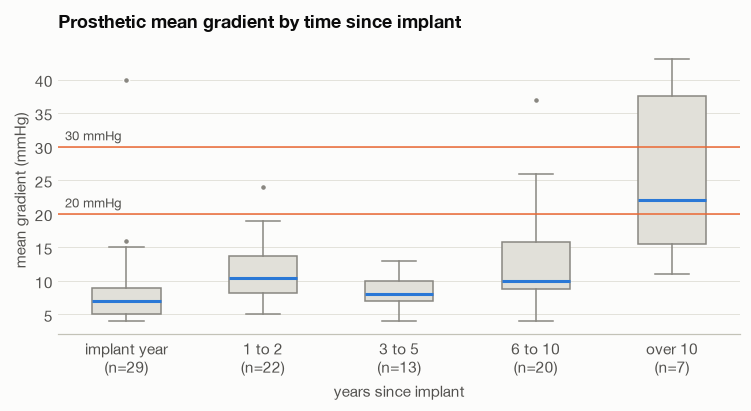

In [12]:
echo_timeline = prep.build_echo_timeline(raw, implants, CONFIG)
assert echo_timeline.episode_id.notna().all()
assert echo_timeline.groupby("episode_id").is_reference.sum().le(1).all()
per_episode = echo_timeline.groupby("episode_id").agg(studies=("study_id", "size"), has_reference=("is_reference", "any"), follow_up=("years_since_reference", lambda s: (s > 0).any()))
display(pd.Series({
    "prosthetic echo studies": len(echo_timeline),
    "valves with any echo": len(per_episode),
    "valves with a reference echo": int(per_episode.has_reference.sum()),
    "valves with an echo after the reference": int(per_episode.follow_up.sum()),
    "valves whose reference echo has a mean gradient": int((echo_timeline.is_reference & echo_timeline.mean_gradient_mmhg.notna()).sum()),
    "mean gradient confirmed by the rules reading": f"{echo_timeline.mean_gradient_confirmed_by_rules.mean():.0%}",
    "studies with a value filled from the rules reading": int(echo_timeline.values_from_rules.ne("").sum()),
}, name="value").to_frame())

bins = pd.cut(echo_timeline.years_since_implant, [-1, 0, 2, 5, 10, 30], labels=["implant year", "1 to 2", "3 to 5", "6 to 10", "over 10"])
groups = [echo_timeline.loc[bins == b, "mean_gradient_mmhg"].dropna() for b in bins.cat.categories]
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.boxplot(groups, tick_labels=[f"{b}\n(n={len(g)})" for b, g in zip(bins.cat.categories, groups)], widths=0.5, patch_artist=True,
           boxprops=dict(facecolor=viz.GRID, color=viz.MUTED), medianprops=dict(color=viz.SERIES[0], linewidth=2),
           whiskerprops=dict(color=viz.MUTED), capprops=dict(color=viz.MUTED), flierprops=dict(marker="o", markersize=4, markerfacecolor=viz.MUTED, markeredgecolor=viz.SURFACE))
for y, label in [(20, "20 mmHg"), (30, "30 mmHg")]:
    ax.axhline(y, color=viz.SERIES[1], linewidth=1)
    ax.text(0.55, y + 0.5, label, va="bottom", fontsize=8.5, color=viz.INK_SECONDARY)
ax.set_ylabel("mean gradient (mmHg)")
ax.set_xlabel("years since implant")
ax.grid(axis="x", visible=False)
ax.set_title("Prosthetic mean gradient by time since implant")
viz.save(fig, "02_gradient_by_time")
plt.show()

## 6. Events

Two sources of valve failure, each tied to the valve it happened to:

- **Echo (VARC-3 haemodynamic valve deterioration).** Compared with the reference echo: stage 2 when the mean gradient rises by 10 mmHg or more to at least 20, or intraprosthetic regurgitation worsens by one grade or more to at least moderate; stage 3 when the gradient rises by 20 or more to at least 30, or regurgitation worsens by two grades to severe. VARC-3 also asks for a fall in EOA or DVI; that confirmation is recorded and becomes required when `require_eoa_or_dvi_confirmation` is on. Paravalvular regurgitation does not count.
- **Reintervention (VARC-3 bioprosthetic valve failure stage 2).** Redo SAVR, valve-in-valve TAVR or balloon valvuloplasty on the valve.

The event year is only known within an interval (last clear echo to first abnormal one, or index operation to the note that reports the reintervention). `event_year_rule` picks the midpoint or the upper end.

Structural or not is a clinical call. Until the clinicians answer, a provisional rule marks an event non-structural when the patient's notes mention endocarditis, thrombosis, paravalvular leak or patient-prosthesis mismatch between the valve's implant and the event, or the written reason says so. Mismatch does not rule out an echo-detected event, because mismatch is present from implant and cannot explain a rise of 10 mmHg or more over the valve's own reference (`ppm_excludes_echo_events`). Their answers go in `data/event_adjudication.csv` (columns `event_id`, `is_structural`, `varc3_category`); this cell writes a blank template and reads the answers when they exist.

In [13]:
events = prep.build_events(raw, implants, echo_timeline, ADJUDICATION_CSV, CONFIG)
template = OUT / "event_adjudication_template.csv"
events.assign(is_structural_provisional=events.is_structural, is_structural="", varc3_category="")[
    ["event_id", "source", "event_type", "year_low", "year_high", "is_structural_provisional", "non_structural_evidence", "reason_as_written", "note_id", "is_structural", "varc3_category"]
].to_csv(template, index=False)
display(pd.crosstab(events.event_type, events.is_structural.map({True: "structural (provisional)", False: "non-structural (provisional)"}), margins=True, margins_name="total"))
pd.Series({"events adjudicated": int(events.adjudicated.sum()), "events awaiting adjudication": int((~events.adjudicated).sum()),
           "median width of event-year interval": float((events.year_high - events.year_low).median())}, name="value").to_frame()

is_structural,non-structural (provisional),structural (provisional),total
event_type,,,
HVD stage 2,3,1,4
reintervention: balloon valvuloplasty,0,1,1
reintervention: redo SAVR,3,3,6
reintervention: valve-in-valve TAVR,2,5,7
total,8,10,18


,value
events adjudicated,0.0
events awaiting adjudication,18.0
median width of event-year interval,9.0


## 7. Follow-up and censoring

Each valve is followed from its reference echo to the first structural event. Without one, follow-up ends at a non-structural reintervention (the valve is replaced for another reason) or at the patient's last contact: the latest year in any note, lab or medication row.

Death is not in the extract, so it cannot be a competing event yet. `vital_status` stays empty until the data request is answered.

Output: `follow_up`, one row per valve.

status,censored,svd
end_reason,,
HVD stage 2,0,1
last contact,20,0
last echo,94,0
non-structural reintervention,5,0
reintervention: balloon valvuloplasty,0,1
reintervention: redo SAVR,0,3
reintervention: valve-in-valve TAVR,0,5


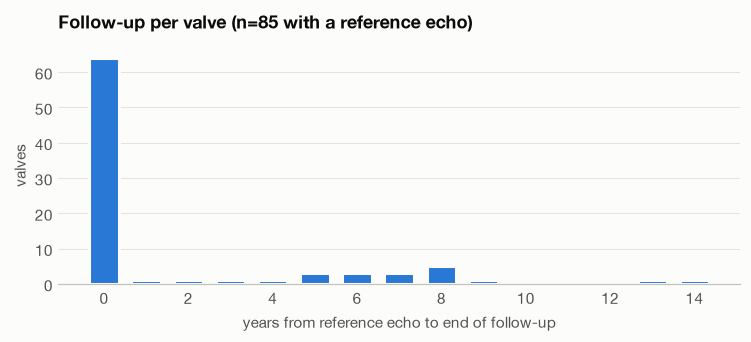

In [14]:
contact = prep.last_contact(raw, labs, meds, CONFIG)
follow_up = prep.build_follow_up(implants, events, echo_timeline, contact, CONFIG)
display(pd.crosstab(follow_up.end_reason, follow_up.status))
fy = follow_up.follow_up_years.dropna().astype(int)
fig, ax = plt.subplots(figsize=(8, 2.8))
counts = fy.value_counts().sort_index()
ax.bar(counts.index, counts.values, width=0.7, color=viz.SERIES[0], edgecolor=viz.SURFACE, linewidth=2)
ax.set_xlabel("years from reference echo to end of follow-up")
ax.set_ylabel("valves")
ax.grid(axis="x", visible=False)
ax.set_title(f"Follow-up per valve (n={len(fy)} with a reference echo)")
viz.save(fig, "02_follow_up")
plt.show()

## 8. Medication exposure by patient and year

Two sources. The medication file covers the 17 patients with structured data; the note text (`antithrombotic_therapy_as_written`, `statin_as_written`) covers everyone for anticoagulants, antiplatelets and statins. Inpatient orders are left out by default (`med_modes`) because orders during a surgical stay are not long-term exposure.

Output: `med_exposure`, one row per patient, year, drug class and source.

In [15]:
med_exposure = prep.build_med_exposure(meds, raw, CONFIG)
med_exposure.groupby(["drug_class", "source"]).patient.nunique().unstack(fill_value=0).rename_axis(columns="patients with any exposure")

patients with any exposure,medication file,note text
drug_class,,
antiplatelet,16,74
calcium_or_vitamin_d,8,0
doac,3,16
loop_diuretic,17,0
raas_inhibitor,13,0
sglt2_inhibitor,3,0
statin,16,67
vka,6,14


## 9. Patient covariates

Sex and comorbidities are collapsed across a patient's notes: a yes in any note beats a no, and a no beats not stated. Height and weight are parsed from the body-size text (cm, m, feet and inches, kg, lb) and give BSA (Mosteller) and BMI. Age is redacted everywhere and stays empty so the landmark table has the shape it would have with real data.

In [16]:
covariates = prep.build_covariates(raw, cohort)
filled = covariates.drop(columns=["patient", "group"]).apply(lambda s: s.notna() & s.ne("not stated")).groupby(covariates.group).mean()
filled.T.map("{:.0%}".format).rename_axis("share of patients with a value")

group,"operative notes, no structured data","structured history, one note"
share of patients with a value,,
sex,91%,100%
height_cm,42%,44%
weight_kg,54%,69%
diabetes,26%,56%
chronic_kidney_disease_or_dialysis,25%,31%
atrial_fibrillation,33%,62%
hypertension,66%,81%
hyperlipidemia,60%,88%
coronary_artery_disease,80%,69%


## 10. Landmark dataset

One row per valve per landmark year. Landmarks are the reference year and 1, 3 and 5 years after it (`fixed_landmarks`), plus every later echo year, while the valve is still event-free and followed.

Features use only data dated at or before the landmark year:
- echo: latest mean and peak gradient, DVI, EOA, indexed EOA, regurgitation, LVEF; reference values; change from reference; slope over the last two studies; number of echoes, echoes in the last two years, years since the last one
- valve: procedure, approach, valve type, name level, size, native morphology, concomitant CABG, index or reintervention valve
- patient: sex, comorbidities, BSA, BMI
- labs and medications in the `lab_lookback_years` before the landmark

Outcome: years to the end of follow-up and its status, and SVD within 2 and 5 years (empty when follow-up ends earlier without an event). `split_year` is the implant year for temporal validation.

In [17]:
landmark = prep.build_landmark(implants, echo_timeline, follow_up, lab_clean, med_exposure, covariates, CONFIG)
assert (landmark.landmark_year < landmark.landmark_year + landmark.time_to_end).all()
blocks = {
    "echo": [c for c in landmark if c.endswith(("_latest", "_reference", "_change", "_slope"))],
    "labs": [c for c in landmark if c.startswith("lab_")],
    "patient": ["sex", "bsa_m2", "bmi", "diabetes", "chronic_kidney_disease_or_dialysis", "atrial_fibrillation"],
    "valve": ["procedure", "valve_type", "valve_size_mm", "native_valve_morphology"],
}
share = pd.DataFrame({b: landmark[cols].apply(lambda s: s.notna() & s.ne("not stated")).mean(axis=1).groupby(landmark.group).mean() for b, cols in blocks.items()})
display(share.map("{:.0%}".format).rename_axis(index="group", columns="average share of features filled"))
display(pd.crosstab(landmark.landmark_type, landmark.group, margins=True, margins_name="total"))
landmark.to_parquet(OUT / "landmark.parquet", index=False)
for name, df in dict(cohort=cohort, lab_clean=lab_clean, implants=implants, echo_timeline=echo_timeline, events=events, follow_up=follow_up, med_exposure=med_exposure, covariates=covariates).items():
    df.to_parquet(OUT / f"{name}.parquet", index=False)
pd.Series({"rows": len(landmark), "valves": landmark.episode_id.nunique(), "patients": landmark.patient.nunique(), "columns": landmark.shape[1]}, name="landmark").to_frame()

average share of features filled,echo,labs,patient,valve
group,,,,
"operative notes, no structured data",16%,0%,57%,93%


group,"operative notes, no structured data",total
landmark_type,,
echo,1,1
fixed +0y,21,21
fixed +1y,20,20
fixed +3y,18,18
fixed +5y,14,14
total,74,74


,landmark
rows,74
valves,21
patients,21
columns,77


## 11. Coverage report

What this extract supports. These numbers feed the limitations section of the protocol.

In [18]:
prep.coverage_report(cohort, implants, echo_timeline, events, follow_up, landmark, conflicts, CONFIG)

,value
patients in extract,117
patients included,116
valve episodes,129
episodes with known implant year,117
prosthetic echo studies,204
episodes with a reference echo,85
episodes with a follow-up echo after the reference,17
candidate events,18
structural events (provisional unless adjudicated),10
episodes ending in SVD,10


## 12. Sensitivity to preprocessing choices

The same pipeline rerun with one choice changed at a time. Large swings show which decisions the result depends on.

In [19]:
variants = {
    "default": {},
    "event year = first abnormal": dict(event_year_rule="upper"),
    "reference window 2 years": dict(reference_window_years=2),
    "reference = first study in window, gradient or not": dict(reference_prefers_gradient=False),
    "no values filled from the rules reading": dict(fill_from_rules=False),
    "mismatch excludes echo-detected events": dict(ppm_excludes_echo_events=True),
    "require EOA or DVI confirmation": dict(require_eoa_or_dvi_confirmation=True),
    "HVD without reference (absolute thresholds)": dict(hvd_without_reference=True),
    "ignore dates written in notes": dict(use_written_dates=False),
}
rows = {}
for name, change in variants.items():
    cfg = {**CONFIG, **change}
    imp, conf = prep.build_implants(raw, cohort, meds, cfg)
    et = prep.build_echo_timeline(raw, imp, cfg)
    ev = prep.build_events(raw, imp, et, ADJUDICATION_CSV, cfg)
    fu = prep.build_follow_up(imp, ev, et, contact, cfg)
    lm = prep.build_landmark(imp, et, fu, lab_clean, med_exposure, covariates, cfg)
    rows[name] = {
        "valves with reference echo": int(et.groupby("episode_id").is_reference.any().sum()),
        "reference echo with mean gradient": int((et.is_reference & et.mean_gradient_mmhg.notna()).sum()),
        "structural events": int(ev.is_structural.sum()),
        "landmark rows": len(lm),
        "rows with 5-year outcome": int(lm.svd_within_5y.notna().sum()) if len(lm) else 0,
        "SVD within 5 years": int(lm.svd_within_5y.eq(1).sum()) if len(lm) else 0,
    }
pd.DataFrame(rows).T

,valves with reference echo,reference echo with mean gradient,structural events,landmark rows,rows with 5-year outcome,SVD within 5 years
default,85,33,10,74,49,12
event year = first abnormal,85,33,10,77,56,3
reference window 2 years,88,36,10,72,49,12
"reference = first study in window, gradient or not",85,16,10,78,49,12
no values filled from the rules reading,85,32,10,74,49,12
mismatch excludes echo-detected events,85,33,9,74,49,9
require EOA or DVI confirmation,85,33,10,74,49,12
HVD without reference (absolute thresholds),85,33,13,74,49,12
ignore dates written in notes,83,31,9,73,49,12
